# Directivité de source — exploration physique et sonore

Ce notebook explore les modèles ajoutés dans `src/scene/` :

- `scene.Directivity` (`PistonDirectivity`, `CardioidDirectivity`, `OmnidirectionalDirectivity`) **directivité d'émission** de la source.
- `scene.SourceOrientation` (`FixedOrientation`, `VelocityOrientation`, `OrientationWaypoints`) **orientation de la source** au fil du temps.


Rappel du principe :
- La **HRTF** modélise la directivité de **réception** : comment la tête de l'auditeur filtre selon la direction *d'où arrive* le son.
- La **directivité de source** (ce notebook) modélise la directivité d'**émission** : combien d'énergie/quel timbre la source envoie *dans telle direction*, relativement à son propre axe.

Ce sont deux filtres indépendants, en cascade, évalués sur deux angles différents — cf. `geometry.emission_angle_deg()` (émission) vs `Listener`/`_listener_relative` (réception, côté `DynamicConvolver`).

In [1]:
import sys
from pathlib import Path
_root = Path.cwd().parent  # notebooks/ -> project root
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
ROOT = _root

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display, Markdown

from scene import (
    PistonDirectivity, CardioidDirectivity, OmnidirectionalDirectivity,
    FixedOrientation, VelocityOrientation, OrientationWaypoints,
    CircularTrajectory, RectilinearTrajectory,
)
from scene.geometry import emission_angle_deg, spherical_to_cartesian

## 1. Instancier un modèle de directivité

`radius_m` est le rayon caractéristique de la source :
- **voix / bouche** : ~1.5–2.5 cm
- **haut-parleur** : rayon réel du diaphragme (souvent 3–15 cm)

Plus `radius_m` est grand, plus la source devient directive tôt en fréquence (`ka ≳ 1` atteint à plus basse fréquence).

In [3]:
piston = PistonDirectivity(radius_m=0.02, floor_db=-26.0)   # ~bouche
print(piston)

cardioid = CardioidDirectivity(order=1.5)   # comparaison : modèle indépendant de la fréquence
omni     = OmnidirectionalDirectivity()     # référence neutre (aucun effet)

PistonDirectivity(radius_m=0.02, floor_db=-26.0)


## 2. Carte directivité (angle × fréquence)

Vue "fiche technique haut-parleur" : le gain `D(θ,f)` en dB, colorée, avec l'angle en ordonnée et la fréquence (log) en abscisse. On doit voir clairement que le lobe se resserre (couleurs sombres qui grimpent plus tôt vers les petits angles) à mesure que la fréquence augmente  et rester à 0 dB sur tout l'axe θ=0°.

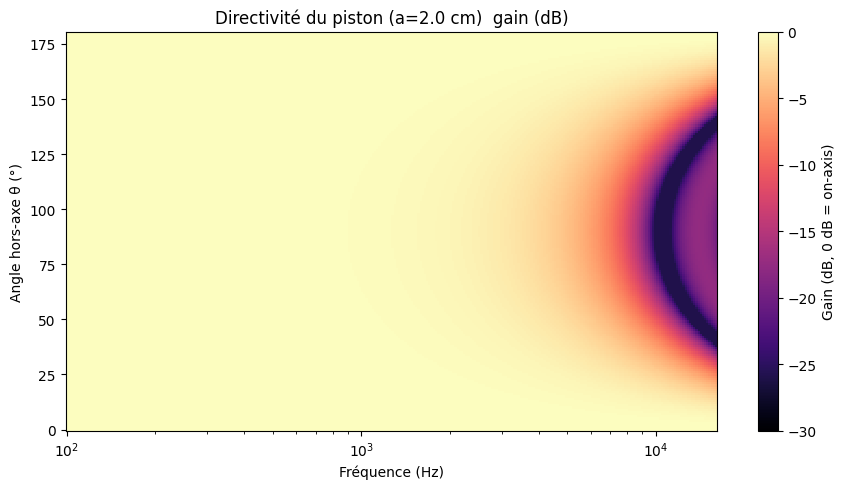

In [5]:
freqs  = np.logspace(np.log10(100), np.log10(16000), 300)
thetas = np.linspace(0, 180, 181)

D_db = np.array([piston.gain_db(th, freqs) for th in thetas])  # shape (n_theta, n_freq)

fig, ax = plt.subplots(figsize=(9, 5))
mesh = ax.pcolormesh(freqs, thetas, D_db, shading="auto", cmap="magma", vmin=-30, vmax=0)
ax.set_xscale("log")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Angle hors-axe θ (°)")
ax.set_title(f"Directivité du piston (a={piston.radius_m*100:.1f} cm)  gain (dB)")
fig.colorbar(mesh, ax=ax, label="Gain (dB, 0 dB = on-axis)")
plt.tight_layout()
plt.show()

## 3. Diagrammes polaires à fréquences fixes

Coupes à fréquence constante ("balloon slices")

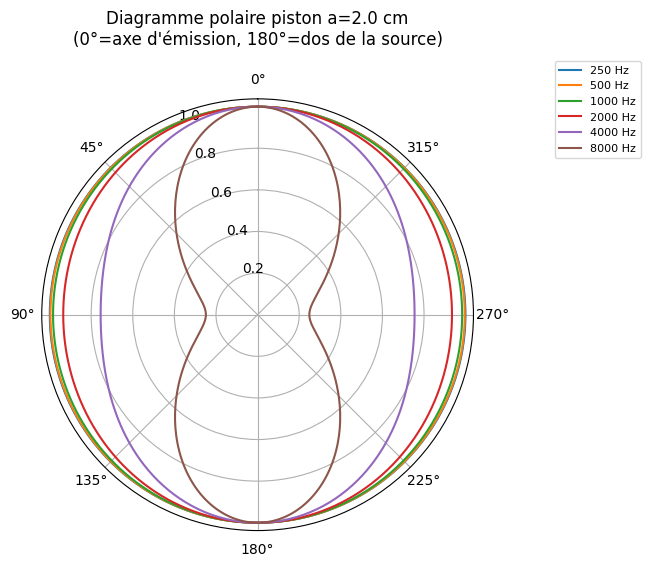

In [7]:
freqs_slice = [250, 500, 1000, 2000, 4000, 8000]
theta_full  = np.linspace(0, 360, 361)
theta_eff   = np.minimum(theta_full, 360 - theta_full)   # replie sur [0°,180°] (symétrie de révolution)

fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection="polar")
for f in freqs_slice:
    mags = piston.magnitude(theta_eff, np.full_like(theta_eff, f))
    ax.plot(np.deg2rad(theta_full), mags, label=f"{f} Hz")

ax.set_theta_zero_location("N")
ax.set_theta_direction(1)
ax.set_title(f"Diagramme polaire piston a={piston.radius_m*100:.1f} cm\n"
             f"(0°=axe d'émission, 180°=dos de la source)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

## 4. Distribution spatiale en 3D  diagramme "ballon"
on déforme une sphère par le gain `D(θ,f)` (le rayon dans chaque direction = le gain dans cette direction), à une fréquence donnée. Trois fréquences côte à côte pour bien voir le lobe se resserrer.

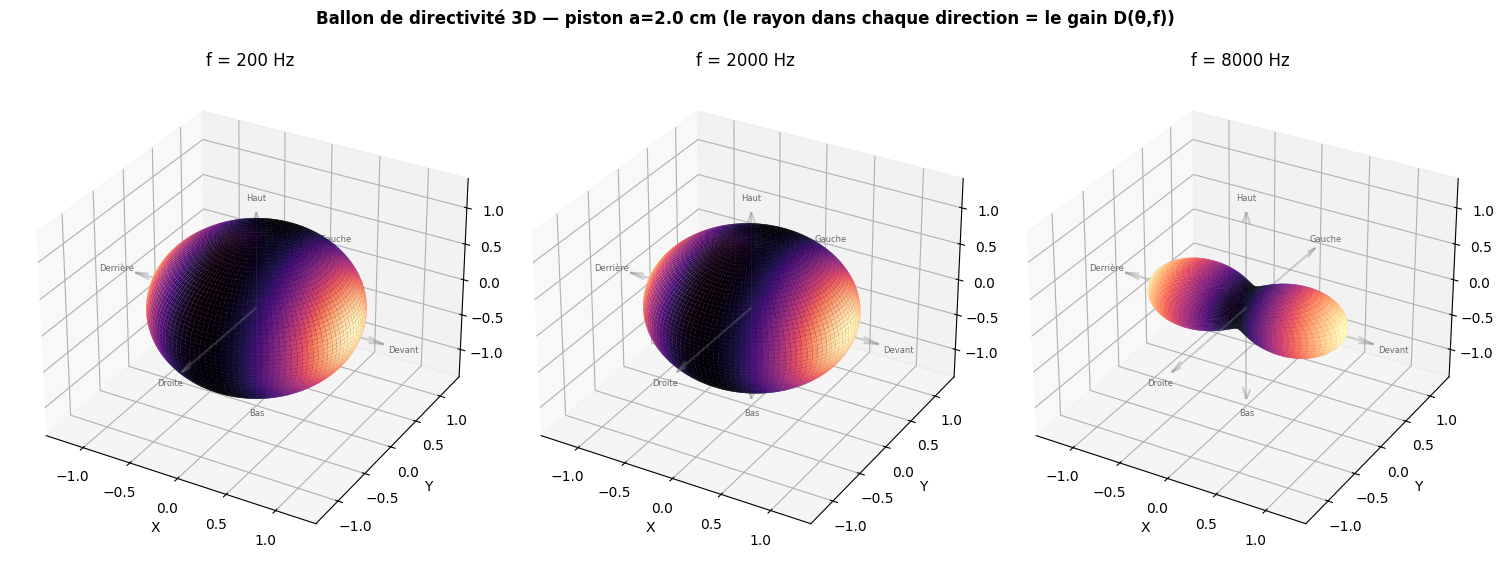

In [8]:
def balloon_surface(directivity, freq_hz, axis_label="Devant (axe d'émission)", n_az=121, n_el=61):
    """Grille (X,Y,Z) et gain D, sphère déformée par la directivité à freq_hz.
    Axe d'émission conventionnel = +x ("devant"), cohérent avec FixedOrientation(0,0)."""
    az = np.linspace(0, 360, n_az)
    el = np.linspace(-90, 90, n_el)
    AZ, EL = np.meshgrid(az, el)
    az_r, el_r = np.deg2rad(AZ), np.deg2rad(EL)

    cos_theta  = np.cos(el_r) * np.cos(az_r)                     # direction(az,el) . (1,0,0)
    theta_grid = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
    D_grid     = directivity.magnitude(theta_grid, np.full_like(theta_grid, freq_hz))

    X = D_grid * np.cos(el_r) * np.cos(az_r)
    Y = D_grid * np.cos(el_r) * np.sin(az_r)
    Z = D_grid * np.sin(el_r)
    return X, Y, Z, D_grid


fig = plt.figure(figsize=(15, 6))
for i, f in enumerate([200, 2000, 8000], start=1):
    X, Y, Z, D_grid = balloon_surface(piston, f)
    ax = fig.add_subplot(1, 3, i, projection="3d")

    colors = plt.cm.magma((D_grid - D_grid.min()) / (D_grid.max() - D_grid.min() + 1e-9))
    ax.plot_surface(X, Y, Z, facecolors=colors, rstride=1, cstride=1,
                     linewidth=0, antialiased=True, shade=False)

    for (dx, dy, dz), lbl in [((1, 0, 0), "Devant"), ((-1, 0, 0), "Derrière"),
                               ((0, 1, 0), "Gauche"), ((0, -1, 0), "Droite"),
                               ((0, 0, 1), "Haut"), ((0, 0, -1), "Bas")]:
        ax.quiver(0, 0, 0, dx * 1.3, dy * 1.3, dz * 1.3, color="gray", alpha=0.35, arrow_length_ratio=0.12)
        ax.text(dx * 1.5, dy * 1.5, dz * 1.5, lbl, fontsize=6, ha="center", va="center", color="dimgray")

    lim = 1.4
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_title(f"f = {f} Hz")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

fig.suptitle(f"Ballon de directivité 3D — piston a={piston.radius_m*100:.1f} cm "
             f"(le rayon dans chaque direction = le gain D(θ,f))", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Appliquer la directivité à un son réel : écoute + spectrogrammes + intensité


In [10]:
# ── Signal à analyser ────────────────────────────────────────────────────
SOUND_PATH = None   # ex: ROOT / "sound" / "mon_son_sec.wav"  (mono ou stéréo, sera converti en mono)

sr          = 44100
duration_s  = 2.0

if SOUND_PATH is not None:
    import soundfile as sf
    dry_signal, sr = sf.read(str(SOUND_PATH), dtype="float32")
    if dry_signal.ndim == 2:
        dry_signal = dry_signal.mean(axis=1)
else:
    rng = np.random.default_rng(0)
    dry_signal = (rng.standard_normal(int(sr * duration_s)) * 0.15).astype(np.float32)

display(Markdown(f"**Signal analysé** : {'fichier ' + str(SOUND_PATH) if SOUND_PATH else 'bruit blanc synthétique'}, "
                  f"{len(dry_signal)/sr:.2f}s @ {sr}Hz"))
display(Audio(dry_signal, rate=sr))

**Signal analysé** : bruit blanc synthétique, 2.00s @ 44100Hz

**θ = 0°**

**θ = 30°**

**θ = 60°**

**θ = 90°**

**θ = 120°**

**θ = 180°**

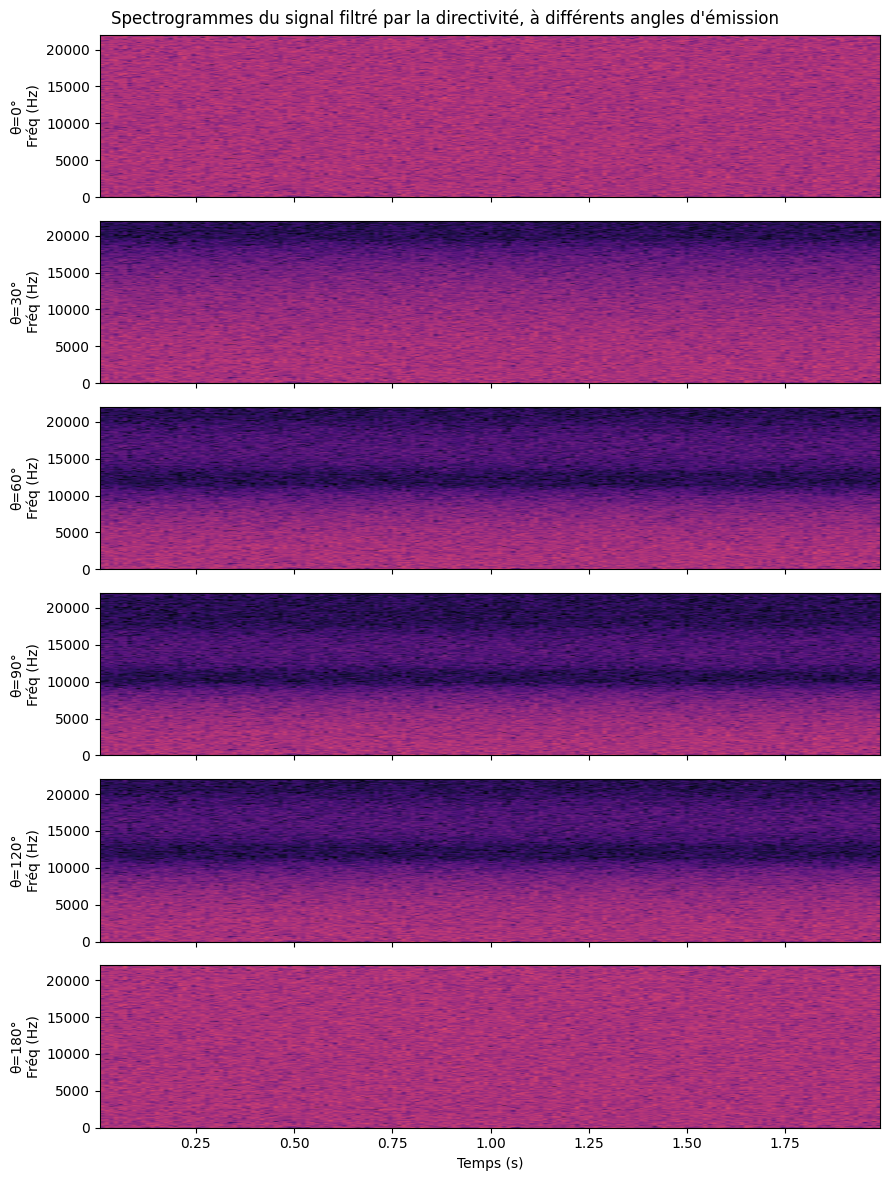

In [11]:
thetas_demo = [0, 30, 60, 90, 120, 180]
n_taps = 257

fig, axes = plt.subplots(len(thetas_demo), 1, figsize=(9, 2.0 * len(thetas_demo)), sharex=True)

for ax, th in zip(axes, thetas_demo):
    filtered = piston.apply(dry_signal, theta_deg=th, sr=sr, n_taps=n_taps)
    display(Markdown(f"**θ = {th}°**"))
    display(Audio(filtered, rate=sr))

    ax.specgram(filtered, Fs=sr, NFFT=1024, noverlap=512, cmap="magma", vmin=-100, vmax=-20)
    ax.set_ylabel(f"θ={th}°\nFréq (Hz)")
    ax.set_ylim(0, sr / 2)

axes[-1].set_xlabel("Temps (s)")
fig.suptitle("Spectrogrammes du signal filtré par la directivité, à différents angles d'émission")
plt.tight_layout()
plt.show()

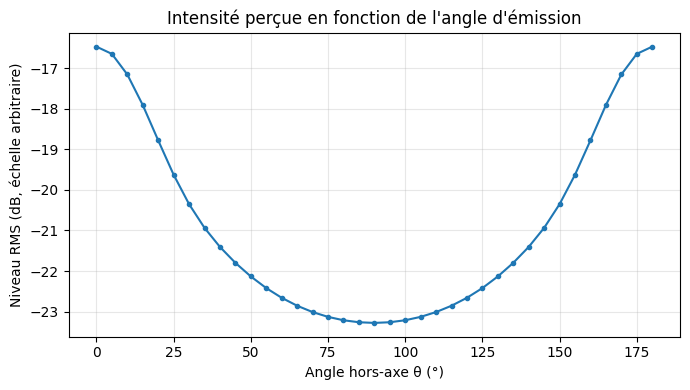

In [12]:
thetas_curve = np.linspace(0, 180, 37)
levels_db = []
for th in thetas_curve:
    filtered = piston.apply(dry_signal, theta_deg=th, sr=sr, n_taps=n_taps)
    rms = np.sqrt(np.mean(filtered ** 2)) + 1e-12
    levels_db.append(20 * np.log10(rms))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thetas_curve, levels_db, marker="o", markersize=3)
ax.set_xlabel("Angle hors-axe θ (°)")
ax.set_ylabel("Niveau RMS (dB, échelle arbitraire)")
ax.set_title("Intensité perçue en fonction de l'angle d'émission")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Orientation dynamique le long d'une trajectoire

Scénario "passage devant l'auditeur" (comme une caisse) : une source suit une corde (`RectilinearTrajectory`) et son axe d'émission suit sa direction de déplacement (`VelocityOrientation`  "elle pointe où elle va"). On observe l'angle d'émission θ(t) vers l'auditeur (fixe, à l'origine) et le gain de directivité résultant à 4 kHz, au cours du temps.


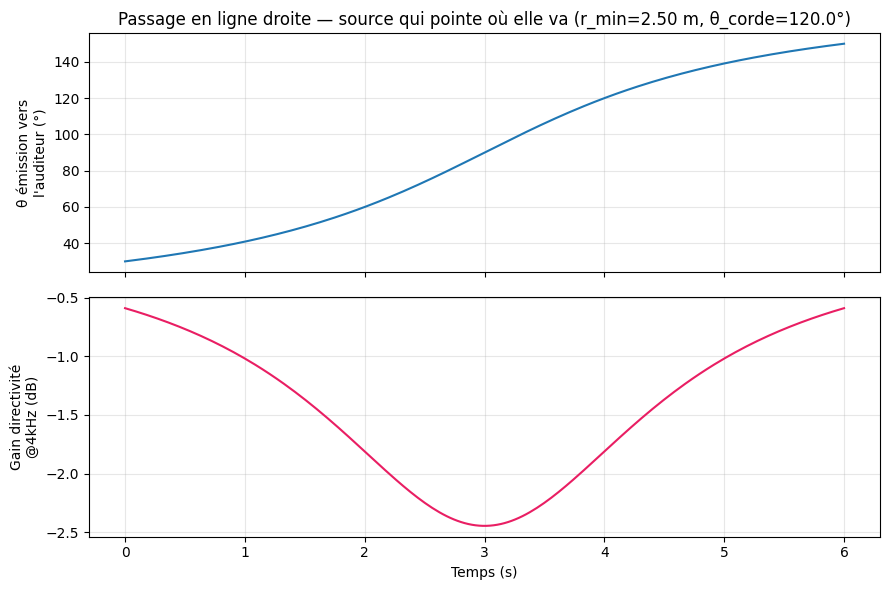

In [13]:
listener_pos = np.array([0.0, 0.0, 0.0])

traj = RectilinearTrajectory(
    duration_s = 6.0,
    start_az   = 150.0, start_el = 0.0,   # arrière-gauche
    end_az     = 30.0,  end_el   = 0.0,   # avant-droite
    R          = 5.0,                     # la corde passe à r_min < R devant l'auditeur
)
orient = VelocityOrientation(traj, R=traj.R)

t_arr = np.linspace(0, traj.duration, 200)
thetas_t = []
for t in t_arr:
    az, el = traj.get_position(t)
    r = traj.get_distance(t)
    source_pos = spherical_to_cartesian(az, el, r)
    direction  = orient.get_direction(t)
    thetas_t.append(emission_angle_deg(direction, source_pos, listener_pos))
thetas_t = np.array(thetas_t)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(t_arr, thetas_t)
axes[0].set_ylabel("θ émission vers\nl'auditeur (°)")
axes[0].set_title(f"Passage en ligne droite — source qui pointe où elle va "
                   f"(r_min={traj.r_min:.2f} m, θ_corde={traj.theta_deg:.1f}°)")
axes[0].grid(alpha=0.3)

gain_t_db = 20 * np.log10(np.maximum(
    np.array([piston.magnitude(th, np.array([4000.0]))[0] for th in thetas_t]), 1e-6
))
axes[1].plot(t_arr, gain_t_db, color="#E91E63")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Gain directivité\n@4kHz (dB)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()